```markdown
## Document Content

| Topic                         |
|-------------------------------|
| Matplotlib: Format Charts     |
| Matplotlib: Pie Plots         |
| Matplotlib: Scatter Plots     |
| Matplotlib: Advanced Customization |
| Matplotlib: Histograms        |
| Matplotlib: Box Plots         |
| Exercise: Skill Pay Analysis  |
| Seaborn: Intro                |
```

# ***Matplotlib: Format Charts***

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset ['train' ]. to_pandas ()

# Data Cleanup
df['job_posted_date'] =pd.to_datetime(df['job_posted_date'])
df ['job_skills'] = df ['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\acer\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


now be built many plots until now so if i want to compare them at one place i use this ie i can grapht everytihng on one figure

### `matplotlib.pyplot.subplots()`: Create a figure and a set of subplots

`plt.subplots()` is a convenient function in Matplotlib to create a figure and a grid of subplots with a single call. It returns a `Figure` object and an `Axes` object or an array of `Axes` objects.

**Syntax:**

```python
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=None, sharex=False, sharey=False, squeeze=True, subplot_kw=None, gridspec_kw=None, **fig_kw)
```

**Key Parameters:**

*   `nrows`, `ncols`: The number of rows and columns of the subplot grid. Defaults to 1x1.
*   `figsize`: A tuple `(width, height)` in inches, specifying the size of the figure.
*   `sharex`, `sharey`: Booleans or {'none', 'all', 'row', 'col'}. Controls sharing of properties among x (or y) axes:
    *   `True` or `'all'`: x (or y) axes will be shared amongst all subplots.
    *   `False` or `'none'`: Each subplot's x (or y) axis is independent.
    *   `'row'`: Each subplot row will share x (or y) axes.
    *   `'col'`: Each subplot column will share x (or y) axes.
*   `squeeze`: If `True` (default), the returned `ax` is squeezed to reduce unnecessary dimensions. For example, if `nrows=1` and `ncols=1`, `ax` will be a single `Axes` object instead of a 2D array with a single element.

**Returns:**

*   `fig`: A `matplotlib.figure.Figure` object.
*   `ax` (or `axs`): A single `matplotlib.axes.Axes` object if `nrows=1` and `ncols=1` and `squeeze=True`. Otherwise, an array (NumPy array) of `Axes` objects, which can be 1D or 2D depending on `nrows` and `ncols`.

[cheatsheet](https://matplotlib.org/cheatsheets/enuanDac)

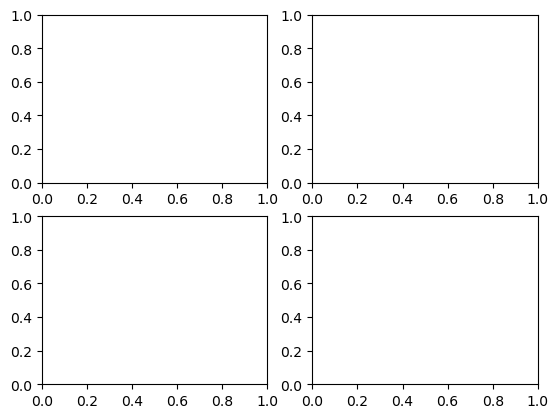

In [6]:
fig, ax = plt.subplots(2,2)

now lets plot 2 plots

In [8]:
df['job_title_short'].value_counts()

job_title_short
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Business Analyst              49063
Software Engineer             44929
Senior Data Engineer          44563
Senior Data Scientist         36957
Senior Data Analyst           29216
Machine Learning Engineer     14080
Cloud Engineer                12331
Name: count, dtype: int64

In [10]:
df['job_schedule_type'].value_counts().head(3)

job_schedule_type
Full-time     701727
Contractor     34793
Internship      8742
Name: count, dtype: int64

<Axes: xlabel='job_schedule_type'>

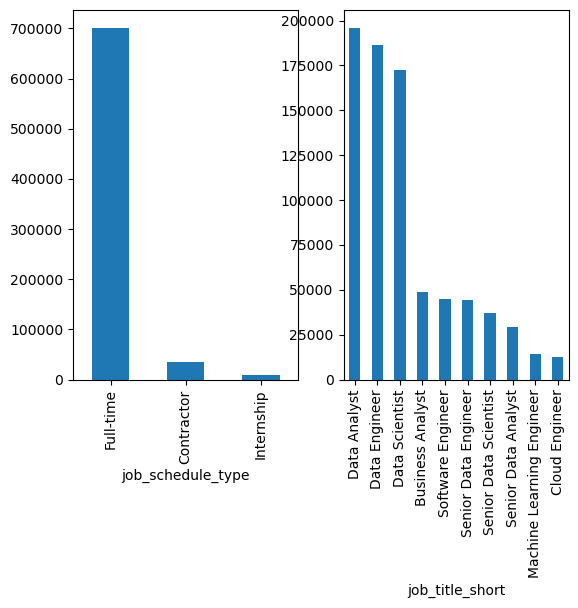

In [ ]:
fig, ax = plt.subplots(1, 2)

df ['job_title_short'].value_counts().plot(kind='bar', ax=ax[1])
df ['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax=ax[0])
# ax=ax[1] these means we need to sepcify the index of ax we are using

we have this overlap we can fix this using a fucntion tight layout

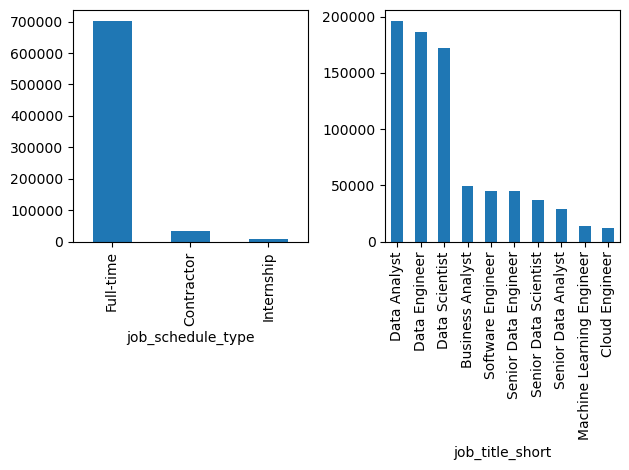

In [12]:
fig, ax = plt.subplots(1, 2)

df ['job_title_short'].value_counts().plot(kind='bar', ax=ax[1])
df ['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax=ax[0])

fig.tight_layout()

here we used pandas method to plot these

now if we use matplotlib we will have:-

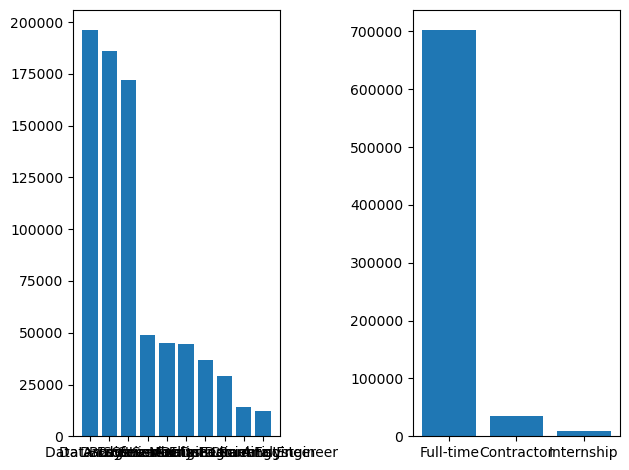

In [13]:
fig, ax = plt.subplots(1, 2)

ax[0].bar(df ['job_title_short']. value_counts() . index, df ['job_title_short' ]. value_counts ( ) )
ax[1].bar(df['job_schedule_type'].value_counts().head(3).index, df ['job_schedule_type'].value_counts().head(3))

plt.tight_layout()

so pandas one is recommended for subplots

now we do an example .. we count jobs of data sci, data engineer, data aalyst all in one sub plot

we will use the same code we used in explode lesson here also

In [14]:
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
skills_count = df_skills.groupby( ['job_skills', 'job_title_short']) .size()
df_skills_count = skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


so first we create a list for the three roles, extract out of that table and then plot

In [15]:
job_titles = ['Data Scientist', 'Data Engineer', 'Data Analyst']

we need to use for loop

0 Data Scientist
1 Data Engineer
2 Data Analyst


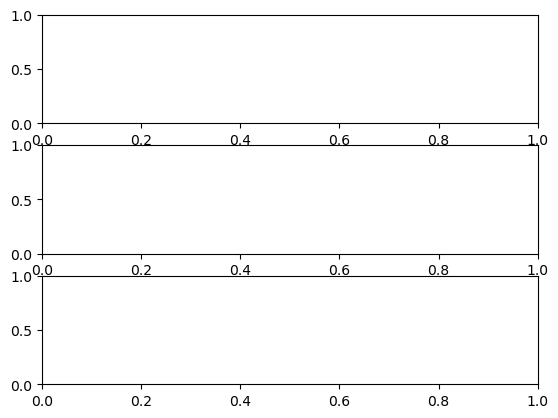

In [ ]:
fig, ax = plt.subplots(3, 1)
#  enumerate() → gives both position and value
for i, job_title in enumerate(job_titles):
 print(i, job_title)
#  i is index , job_title is value

In [ ]:
for i, job_title in enumerate(job_titles):
 print(df_skills_count[df_skills_count['job_title_short'] == job_title].head(5))
#  i         → index (0, 1, 2, ...)
# job_title → actual value ('Data Analyst', ...)

     job_skills job_title_short  skill_count
1480     python  Data Scientist       113711
1823        sql  Data Scientist        78982
1518          r  Data Scientist        59566
1637        sas  Data Scientist        29534
1943    tableau  Data Scientist        29445
     job_skills job_title_short  skill_count
1822        sql   Data Engineer       113130
1479     python   Data Engineer       108022
141         aws   Data Engineer        62049
151       azure   Data Engineer        60674
1772      spark   Data Engineer        53656
     job_skills job_title_short  skill_count
1821        sql    Data Analyst        92428
558       excel    Data Analyst        66860
1478     python    Data Analyst        57190
1941    tableau    Data Analyst        46455
1410   power bi    Data Analyst        39380


now we get this

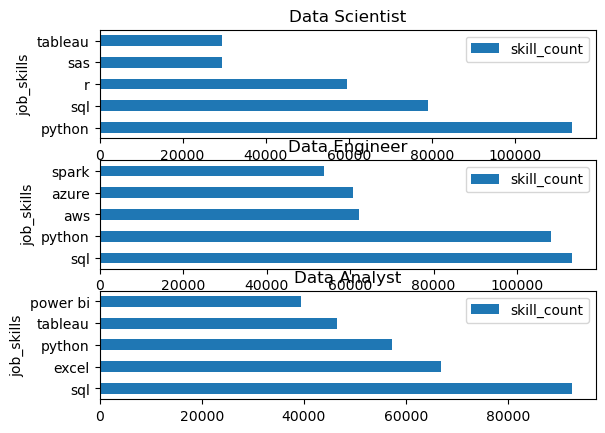

In [18]:
fig, ax = plt.subplots(3, 1)

for i, job_title in enumerate(job_titles):
 df_plot = df_skills_count [df_skills_count['job_title_short'] == job_title].head(5)
 df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title) 

but now lets reverse the axis for this

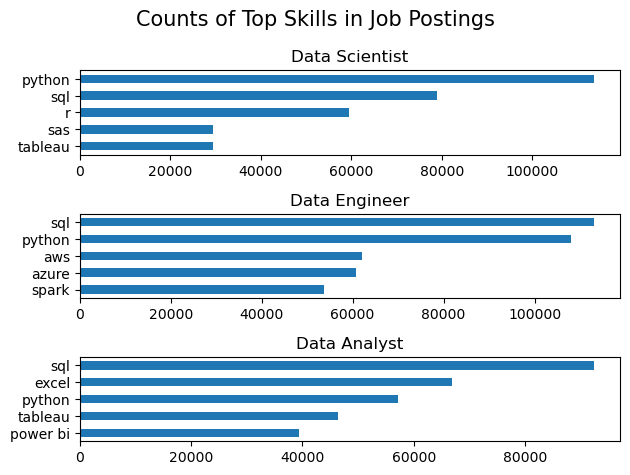

In [ ]:
fig, ax = plt.subplots(3, 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count [df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title) 
    ax[i].invert_yaxis ()
    ax[i] .set_ylabel('') # removes y axis labels
    ax[i].legend().set_visible(False) # removes legend or scale

fig. suptitle('Counts of Top Skills in Job Postings', fontsize=15)
fig.tight_layout()


but  The x-axis scale is not the same for
the 3 plots and thus incomparable. ie for da its 80k and for others its 100k 

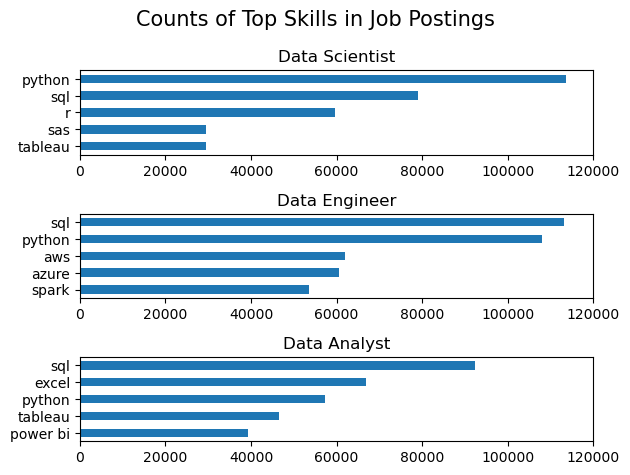

In [23]:
fig, ax = plt.subplots(3, 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count [df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title) 
    ax[i].invert_yaxis ()
    ax[i] .set_ylabel('') # removes y axis labels
    ax[i].legend().set_visible(False) # removes legend or scale
    ax[i].set_xlim(0, 120000) # this one sets x axis for all as 120k

fig. suptitle('Counts of Top Skills in Job Postings', fontsize=15)
fig.tight_layout()

if we use % of skill appearing of a job instead of counts it will look more representative

---

# ***Matplotlib: Pie Plots***

In [25]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset ['train' ]. to_pandas ()

# Data Cleanup
df['job_posted_date'] =pd.to_datetime(df['job_posted_date'])
df ['job_skills'] = df ['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

lets make a pie chart for job work from home

In [26]:
df['job_work_from_home'].value_counts()

job_work_from_home
False    716189
True      69552
Name: count, dtype: int64

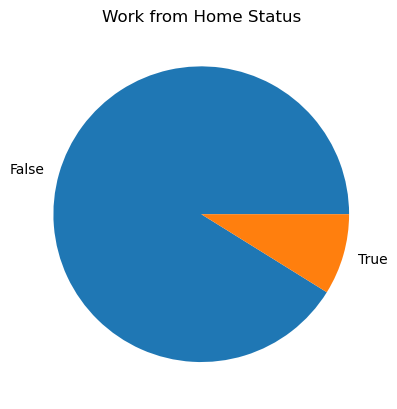

In [28]:
df['job_work_from_home'].value_counts().plot(kind='pie')
plt.title('Work from Home Status')
plt.ylabel("")
plt.show()

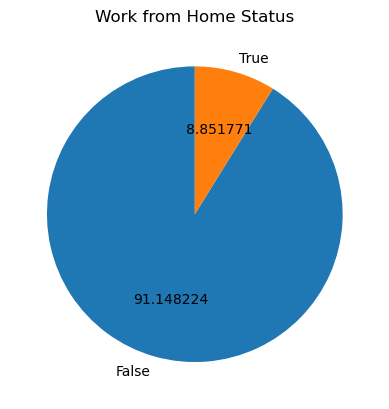

In [ ]:
df['job_work_from_home'].value_counts().plot(kind='pie', startangle=90, autopct='%1f')
# that angle will give us an angle fro where to start pie charts
plt.title('Work from Home Status')
plt.ylabel("")
plt.show()

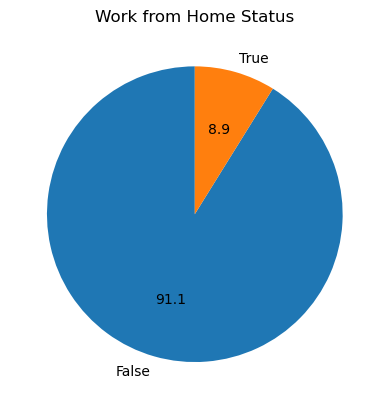

In [ ]:
df['job_work_from_home'].value_counts().plot(kind='pie', startangle=90, autopct='%1.1f')
# 1.1 means i want 1 decimal palce only
plt.title('Work from Home Status')
plt.ylabel("")
plt.show()

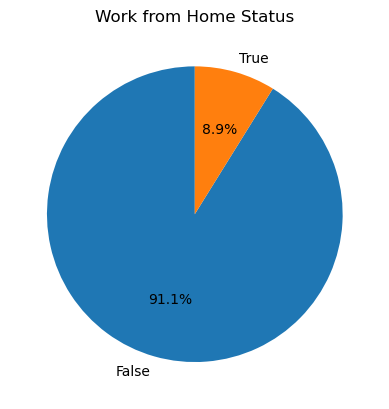

In [ ]:
df['job_work_from_home'].value_counts().plot(kind='pie', startangle=90, autopct='%1.1f%%')
# %% at end for %
plt.title('Work from Home Status')
plt.ylabel("")
plt.show()

In [33]:
df [['job_work_from_home', 'job_no_degree_mention', 'job_health_insurance']]


,job_work_from_home,job_no_degree_mention,job_health_insurance
0,False,False,False
1,False,False,False
2,False,False,False
3,False,True,False
4,False,False,False
...,...,...,...
785736,False,False,False
785737,False,False,False
785738,False,False,False
785739,False,False,False


lets make a pie chart for this 

### `matplotlib.pyplot.pie()`: Create Pie Charts

`plt.pie()` is used to create a pie chart. A pie chart is a circular statistical graphic, which is divided into slices to illustrate numerical proportion. In a pie chart, the arc length of each slice is proportional to the quantity it represents.

**Syntax:**

```python
plt.pie(x, labels=None, autopct=None, explode=None, startangle=None, colors=None, shadow=False, textprops=None, wedgeprops=None)
```

**Key Parameters:**

*   `x`: The wedge sizes. This is an array or list of numerical values representing the proportion of each slice.
*   `labels`: A list of strings used to label each wedge.
*   `autopct`: A string or function used to format the numerical percentage values displayed on the wedges. For example, `'%.1f%%'` will display percentages with one decimal place.
*   `explode`: A sequence of the same length as `x`, where each value specifies how far the respective wedge is offset from the center of the pie.
*   `startangle`: The angle at which the first wedge is drawn, counterclockwise from the x-axis. Default is 0 (3 o'clock).
*   `colors`: A list of colors for the wedges.
*   `shadow`: If `True`, a shadow is drawn beneath the pie.
*   `textprops`: Dictionary of properties to apply to the text labels (e.g., font size, color).
*   `wedgeprops`: Dictionary of properties to apply to the wedges (e.g., width, edgecolor).

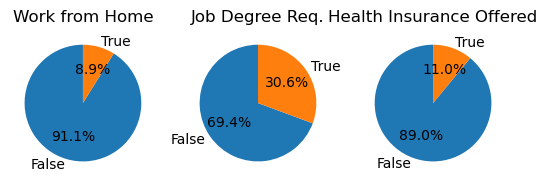

In [36]:
import matplotlib.pyplot as plt

# Create a figure with 3 subplot areas
# 1 row and 3 columns of plots
# fig → whole figure
# ax → list/array of 3 plotting areas
fig, ax = plt.subplots(1, 3)

# Dictionary:
# key   → dataframe column
# value → title for the chart
dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'Job Degree Req.',
    'job_health_insurance': 'Health Insurance Offered'
}

# enumerate() explanation:
# When looping through the dictionary,
# enumerate() gives two values:
# i → index number (0,1,2...)
# (column, title) → key and value from dictionary
#
# We need 'i' so we know which subplot (ax[0], ax[1], ax[2]) to draw on
for i, (column, title) in enumerate(dict_column.items()):

    # Count True/False values in the column
    counts = df[column].value_counts()

    # Plot pie chart on the i-th subplot
    ax[i].pie(
        counts.values,            # sizes of slices
        labels=counts.index,      # labels (True / False)
        startangle=90,
        autopct='%1.1f%%'
    )

    # Set title for that subplot
    ax[i].set_title(title)

# Display all charts
plt.show()



---

# ***Matplotlib: Scatter Plots***

In [55]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset ['train' ]. to_pandas ()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df ['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


<Axes: xlabel='skill_count', ylabel='skill_pay'>

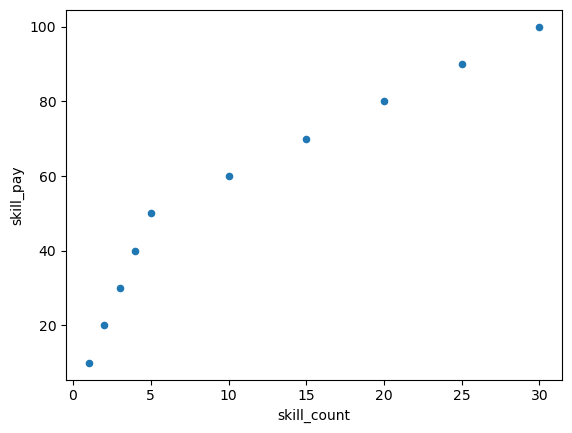

In [37]:
data = {
'job_skills': ['python', 'sql', 'java', 'c++', 'c#', 'javascript', 'html', 'css' , 'php', 'ruby' ],
'skill_count': [30, 25, 20, 15, 10, 5, 4, 3, 2, 1],
'skill_pay': [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]

}

df = pd.DataFrame(data)

df.plot(kind='scatter', x='skill_count', y='skill_pay')

so now we first need to find out job_skills and their count and median salary to make scatter

In [56]:
df = df [df ['job_title_short' ] == 'Data Analyst']
df_exploded = df.explode('job_skills')


now 

In [ ]:
df_exploded.groupby('job_skills').agg(
skill_count=('job_skills', 'count'),
median_salary=('salary_year_avg', 'median')
)
# make new colo skill count and tell him ki on job skills do count and make it as skill count as its in agg only it willl do that agg function

,skill_count,median_salary
job_skills,,
airflow,2002,111175.0
airtable,88,90000.0
alteryx,4570,105000.0
angular,376,109101.0
angular.js,2,NaN
...,...,...
wrike,39,75000.0
wsl,16,NaN
xamarin,2,NaN


In [62]:
skill_stats = df_exploded.groupby('job_skills').agg(
skill_count=('job_skills', 'count'),
median_salary=('salary_year_avg', 'median')
)

skill_stats.sort_values('skill_count' ,ascending= False).head(10)

,skill_count,median_salary
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0


<Axes: xlabel='skill_count', ylabel='median_salary'>

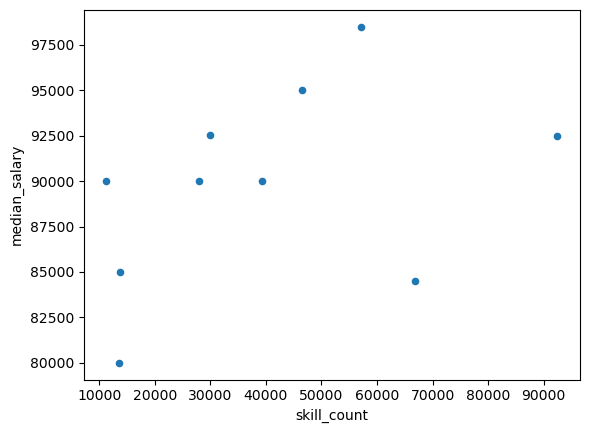

In [63]:
a = skill_stats.sort_values('skill_count' ,ascending= False).head(10)

a.plot(kind='scatter' , x='skill_count'  , y='median_salary')

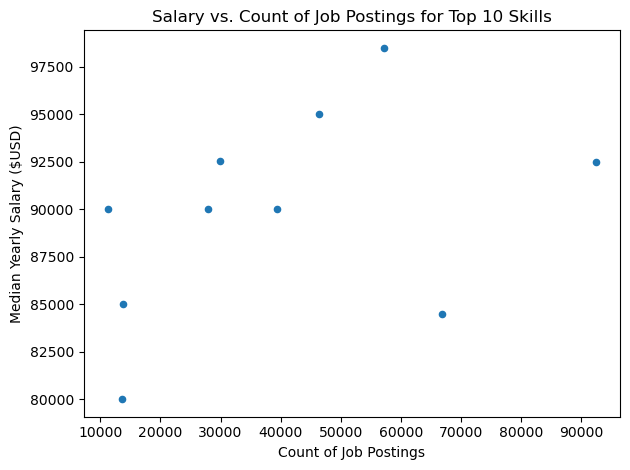

In [64]:
a.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Salary vs. Count of Job Postings for Top 10 Skills')
plt.tight_layout()
plt. show()

### `matplotlib.pyplot.text()`: Add Text to a Plot

`plt.text()` is used to add text labels or annotations to specific locations on your Matplotlib plot (Axes).

**Syntax:**

```python
plt.text(x, y, s, fontdict=None, **kwargs)
```

**Simple Terms:** It places a piece of text (`s`) at a specific coordinate (`x`, `y`) on your graph.

**Key Parameters:**

*   `x`, `y`: These are floating-point numbers that specify the coordinates where the text should be placed on the plot. By default, these are in 'data coordinates' (meaning they correspond to the values on your x and y axes).
*   `s`: This is the string of text you want to display on the plot.
*   `fontdict`: (Optional) A dictionary to control the font properties of the text (e.g., `'fontsize'`, `'fontweight'`, `'color'`).
*   `**kwargs`: You can pass many other keyword arguments to customize the text's appearance and positioning, such as:
    *   `color`: Set the text color.
    *   `fontsize`: Set the font size.
    *   `horizontalalignment` (or `ha`): How the text is aligned horizontally relative to the `x` coordinate (`'left'`, `'center'`, `'right'`). Default is `'left'`.
    *   `verticalalignment` (or `va`): How the text is aligned vertically relative to the `y` coordinate (`'top'`, `'center'`, `'bottom'`, `'baseline'`). Default is `'baseline'`.
    *   `rotation`: Rotate the text (e.g., `90` for vertical).
    *   `bbox`: Add a bounding box around the text (e.g., `dict(boxstyle="round,pad=0.5", fc="yellow", ec="k", lw=1, alpha=0.5)`).

but naming those points via matplotlib is not easy we need to use seaborn

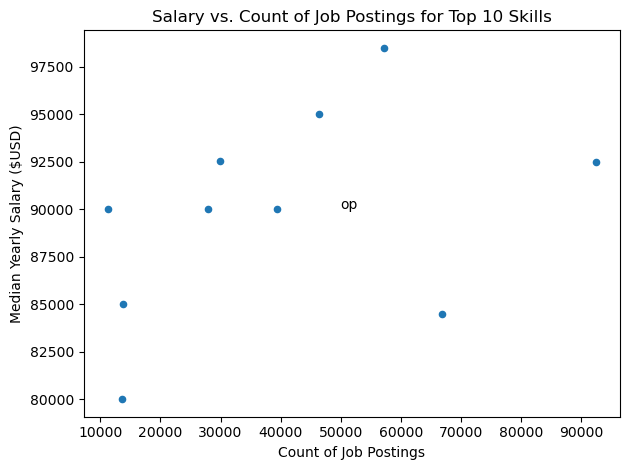

In [65]:
a.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Salary vs. Count of Job Postings for Top 10 Skills')
plt.tight_layout()
plt.text(50000, 90000 , 'op')
plt. show()

for now we use for loop go get us the naming issue

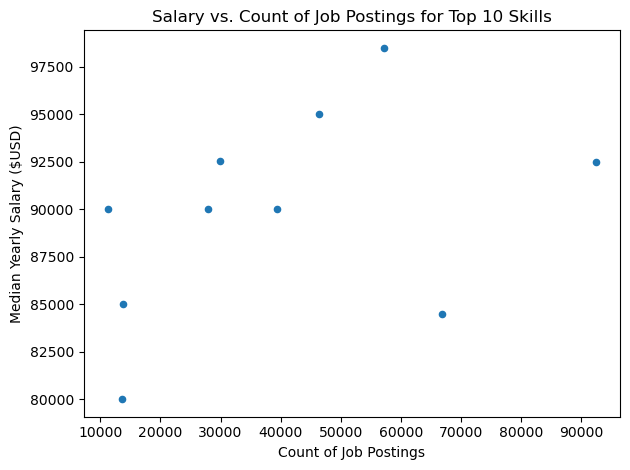

In [70]:
a.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Salary vs. Count of Job Postings for Top 10 Skills')
plt.tight_layout()
plt. show()

In [67]:
# we need index ie i here and coloumn name ie txt here and to get index of a.. we enumertate via a

for i, txt in enumerate(a.index):
 print(i, txt)

0 sql
1 excel
2 python
3 tableau
4 power bi
5 r
6 sas
7 powerpoint
8 word
9 sap


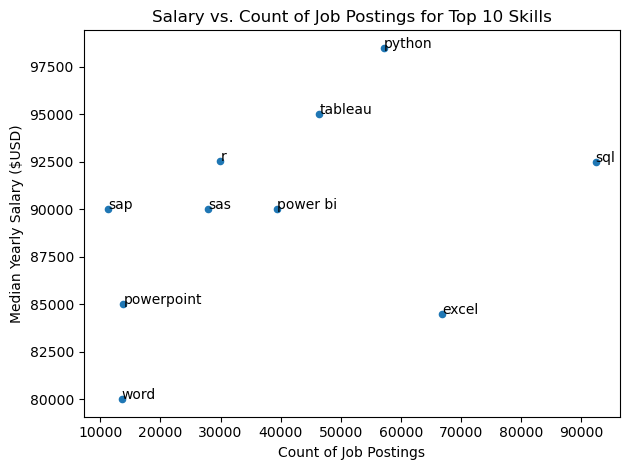

In [73]:
a.plot(kind='scatter', x='skill_count', y='median_salary' )
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Salary vs. Count of Job Postings for Top 10 Skills')
plt.tight_layout ()

for i, txt in enumerate(a.index):
 plt.text(a['skill_count']. iloc[i], a ['median_salary'] . iloc[i], txt)

plt. show()

---

# ***Matplotlib: Advanced Customization***

In [74]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs' )
df = dataset ['train' ]. to_pandas ()

# Data Cleanup
df ['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df ['job_skills'] = df ['job_skills']. apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# Filter for Data Analyst data
df_DA = df [df ['job_title_short' ] == 'Data Analyst']. copy()
# now our df will only contain data analyst data 

Customizing our chart from 12_Exercise_Trending_Skills.ipynb
Let's customize the chart we created a few lessons back.

Here's the all the code for the plot.

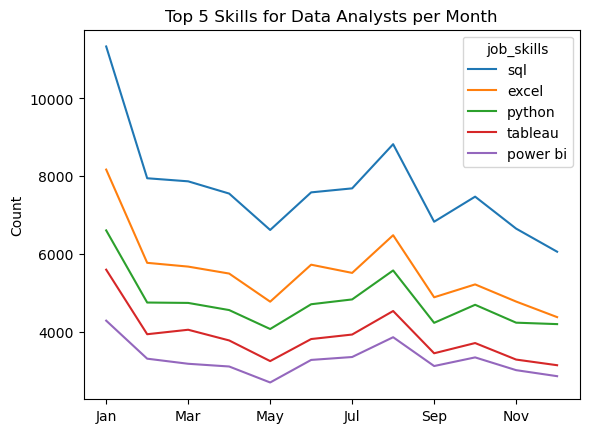

In [75]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()
# create a new column for month number
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month

# Explode the job_skills column and pivot
df_DA_explode= df_DA.explode('job_skills')
df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills',  aggfunc='size', fill_value=0)

# sort the skills by count
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot = df_DA_pivot.drop('Total')

# Use month names for plotting
df_DA_pivot = df_DA_pivot.reset_index()
df_DA_pivot['job_posted_month'] = df_DA_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
df_DA_pivot = df_DA_pivot.drop(columns='job_posted_month_no')

# Get the top 5 skills
df_DA_pivot.iloc[:, :5].plot(kind='line')

plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

In [76]:
df_DA_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,xamarin,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,0,0,0,0,0,1,1,0,0,0
Feb,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
Mar,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,1,0,0,0,0,0,0,0,0,1
Apr,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,0,0,0,0,1,0
May,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,1,0,0
Jun,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
Jul,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
Aug,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
Sep,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,1,0,0,0,0,0,0,0,0


## Basic Plot Customizations

### Line Styles and Colors

**Line Style (`linestyle`)**  
Changes how the line appears in the plot.

Common options:
- `'-'` → solid line  
- `'--'` → dashed line  
- `'-.'` → dash-dot line  
- `':'` → dotted line  

Example: `linestyle='--'`

---

**Line Color (`color`)**  
Changes the color of the line.

Examples:  
`color='blue'`  
`color='red'`

---

**Color Map (`colormap`)**  
Applies a color scheme when plotting multiple columns. Each line will automatically get a different color from the chosen palette.

Common colormaps:
- `viridis`
- `plasma`
- `inferno`
- `magma`
- `cividis`

Example: `colormap='viridis'`

---

### Line Width

**Line Width (`linewidth`)**  
Controls how thick the line appears.

Examples:  
`linewidth=2` → thin line  
`linewidth=4` → thicker line

---

### Markers

**Marker Style (`marker`)**  
Adds symbols to highlight each data point on the line.

Common markers:
- `'o'` → circle  
- `'x'` → cross  
- `'s'` → square  
- `'^'` → triangle  
- `'*'` → star  

Example: `marker='o'`

---

**Marker Size (`markersize`)**  
Controls the size of the marker symbols.

Examples:  
`markersize=5`  
`markersize=8`

now lets go one by one

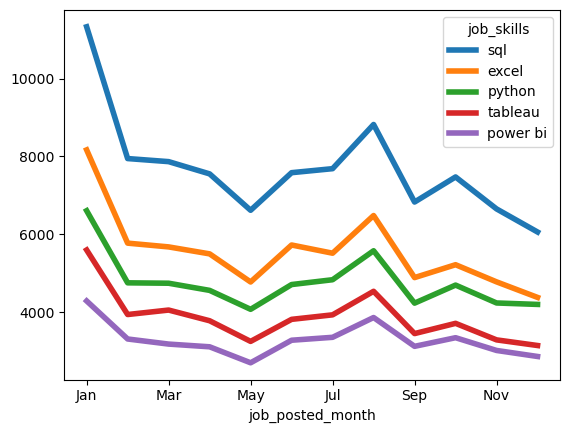

In [ ]:

df_DA_pivot. iloc[:, :5].plot(

kind='line',
linewidth=4
# tell the width of line
)

plt. show()

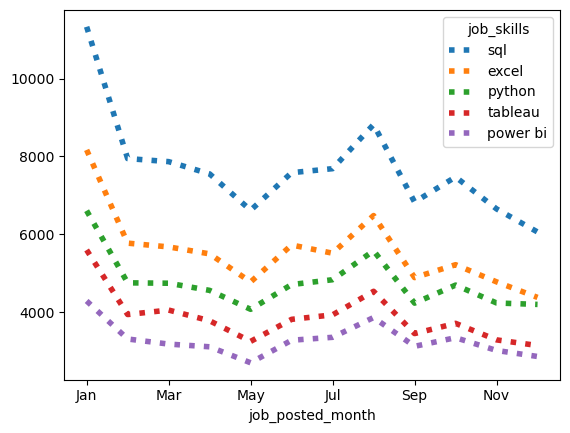

In [81]:

df_DA_pivot. iloc[:, :5].plot(

kind='line',
linewidth=4,
linestyle = ':'
)

plt. show()

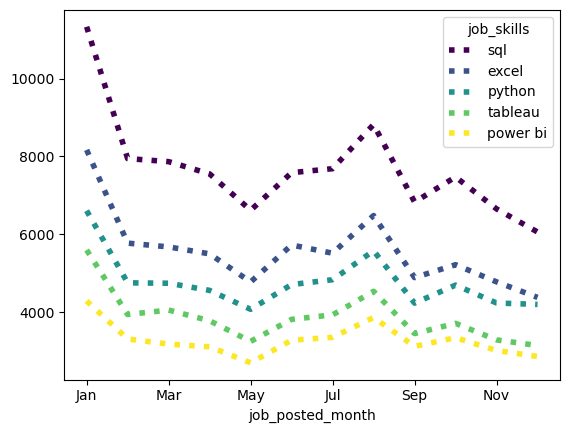

In [86]:

df_DA_pivot. iloc[:, :5].plot(

kind='line',
linewidth=4,
linestyle = ':',
colormap= 'viridis'
)

plt. show()

in matplotlib cheatsheets we have many colour maps

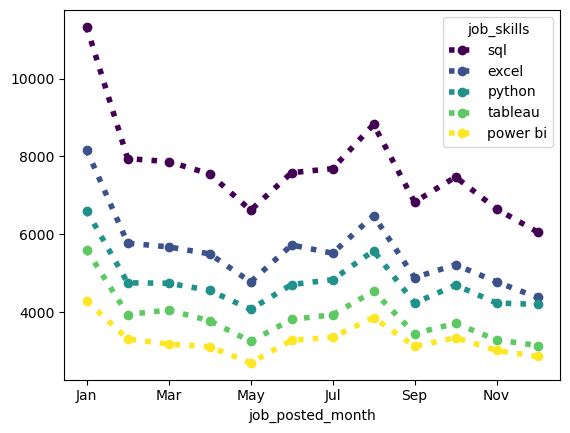

In [92]:
df_DA_pivot. iloc[:, :5].plot(

kind='line',
linewidth=4,
linestyle = ':',
colormap= 'viridis',
marker ='o',

)

plt. show()

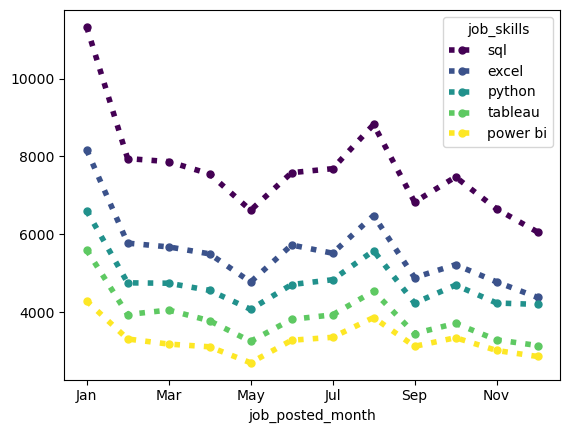

In [93]:
df_DA_pivot. iloc[:, :5].plot(

kind='line',
linewidth=4,
linestyle = ':',
colormap= 'viridis',
marker ='o',
markersize=5,
)

plt. show()

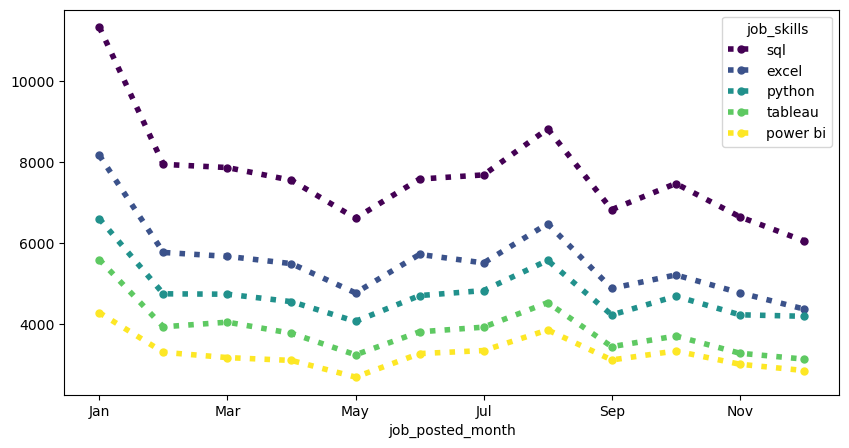

In [95]:
df_DA_pivot. iloc[:, :5].plot(

kind='line',
linewidth=4,
linestyle = ':',
colormap= 'viridis',
marker ='o',
markersize=5,
figsize=(10,5)
)

plt. show()

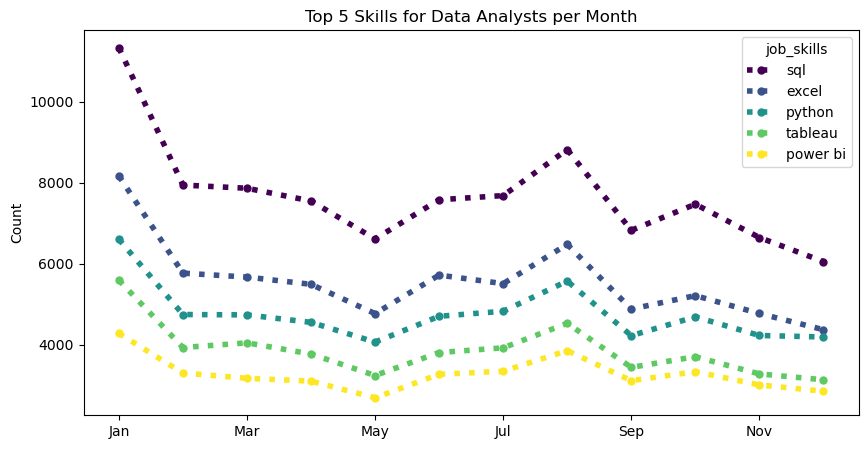

In [96]:
df_DA_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth=4,
    linestyle=':', # options: '-', '--', '-.', ':'
    colormap='viridis', # options: 'viridis', 'plasma', 'inferno', 'magma', 'cividis' 
    markersize=5,
    marker='o', # options: 'o', 'x', '+', '*', 's', ',', '.', '1', '2', '3', '4', ...
    figsize=(10, 5)
)

plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

now the example in previous chapter

In [97]:
# Explode the 'job_skills' into individual rows
df_exploded = df_DA.explode('job_skills')

# Calculate the average salary and count of job postings per skill
skill_stats = df_exploded.groupby('job_skills').agg(
median_salary=('salary_year_avg', 'median'),
skill_count=('job_skills', 'count')

)

# Limit to the top skills
skill_count = 20
skill_stats = skill_stats. sort_values(by='skill_count', ascending=False).head(skill_count)

skill_stats

,median_salary,skill_count
job_skills,,
sql,92500.000000,92428
excel,84479.000000,66860
python,98500.000000,57190
tableau,95000.000000,46455
power bi,90000.000000,39380
r,92527.500000,29996
sas,90000.000000,27998
powerpoint,85000.000000,13822
word,80000.000000,13562


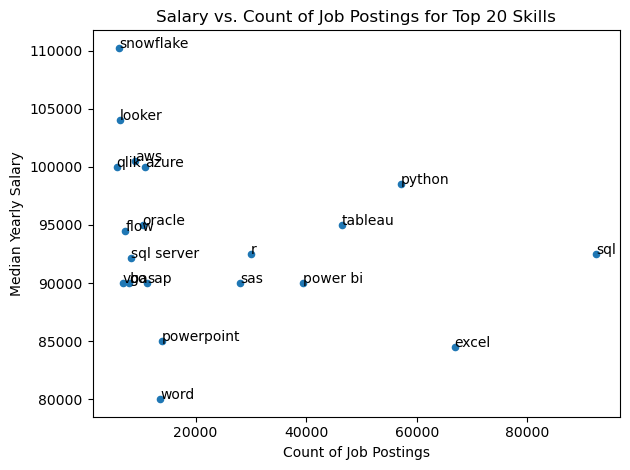

In [99]:
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary' )

for i, txt in enumerate(skill_stats.index):
 plt.text(skill_stats['skill_count']. iloc[i], skill_stats ['median_salary' ]. iloc[i], txt)

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')
plt.tight_layout()
plt.show()

now we use adjust text to fix overlap

we need to download this adjust text in terminal by first conda activate python_course then pip install adjustTextpip show adjustText

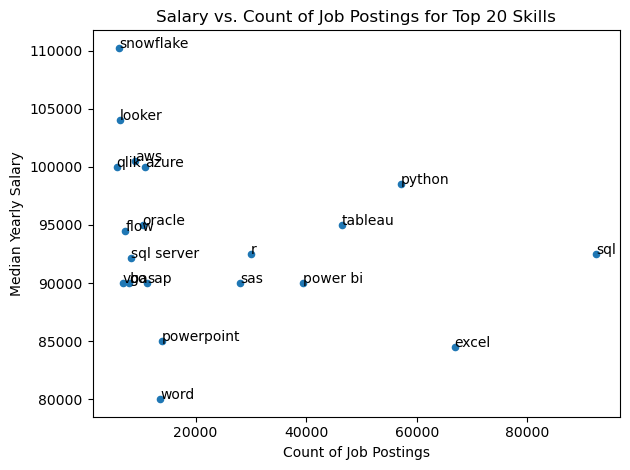

In [ ]:
from adjustText import adjust_text

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary' )

for i, txt in enumerate(skill_stats.index):
 plt.text(skill_stats['skill_count']. iloc[i], skill_stats ['median_salary' ]. iloc[i], txt)

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')
plt.tight_layout()
plt.show()

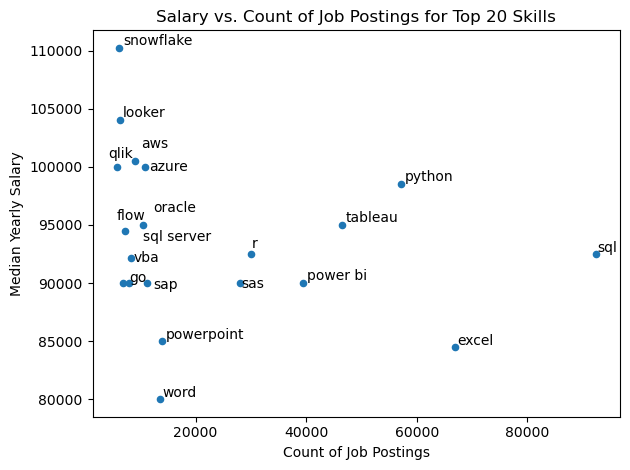

In [ ]:
from adjustText import adjust_text

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary' )

texts = []
# lets make a empty list first
for i, txt in enumerate(skill_stats.index):
 texts.append(plt.text(skill_stats['skill_count']. iloc[i], skill_stats ['median_salary' ]. iloc[i], txt) )
#  these must go inside that list so did append 

adjust_text(texts)

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt. title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')
plt.tight_layout()
plt.show()

but now we need some arrows also

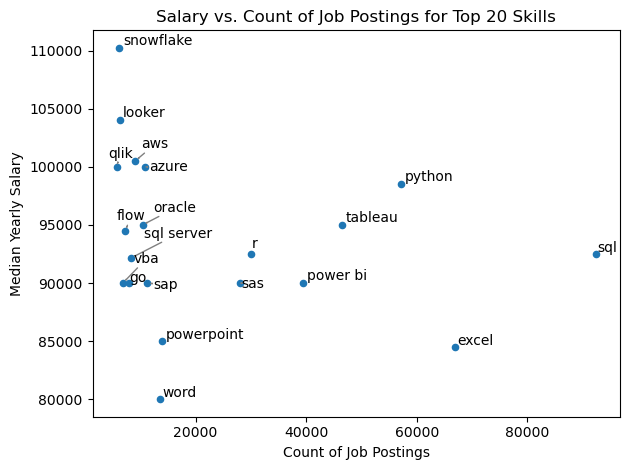

In [108]:
from adjustText import adjust_text

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary' )

texts = []
# lets make a empty list first
for i, txt in enumerate(skill_stats.index):
 texts.append(plt.text(skill_stats['skill_count']. iloc[i], skill_stats ['median_salary' ]. iloc[i], txt) )
#  these must go inside that list so did append 

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='grey', lw=1))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt. title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')
plt.tight_layout()
plt.show()

now customize the y axis

### Matplotlib Tick Formatters and Locators: Simplifying Axis Labels

Matplotlib's `ticker` module provides powerful tools to control how your axis ticks (the small marks along the axis) and their labels (the numbers or text next to them) are displayed. This is especially useful for making plots more readable and customized.

---

#### `matplotlib.ticker.FuncFormatter(func)`: Customizing Tick Labels with a Function

**What it does:** This tool allows you to define your *own function* to format how the numbers or values on your axis ticks appear as text labels. Instead of Matplotlib's default number formatting, you can make them show currency, percentages, dates, or anything custom.

**Simple Terms:** It lets you tell Matplotlib, "For every number on my axis, run it through *my* special function, and whatever text my function gives back, use that as the label."

**How it works:**
*   You create a Python function that takes two inputs:
    *   `x`: The actual numerical value of the tick.
    *   `pos`: The position of the tick (usually not needed for simple formatting).
*   This function *must* return a string, which will be the label for that tick.

**Example Use Case:** Displaying large numbers like `1000` as `1K`, or adding unit symbols like `$` or `%`.


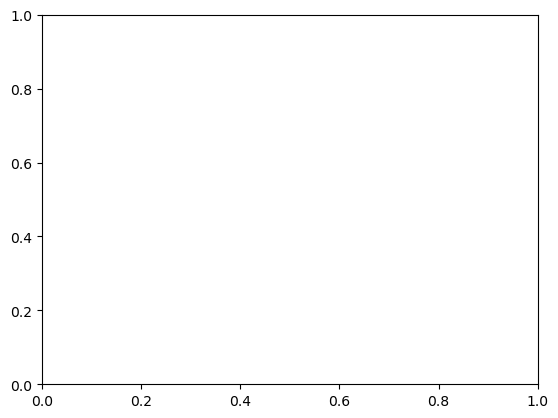

In [ ]:
fig, ax = plt.subplots()
ax = plt.gca()
# its a function it means get current axis but this gca must be called after we generated the plot

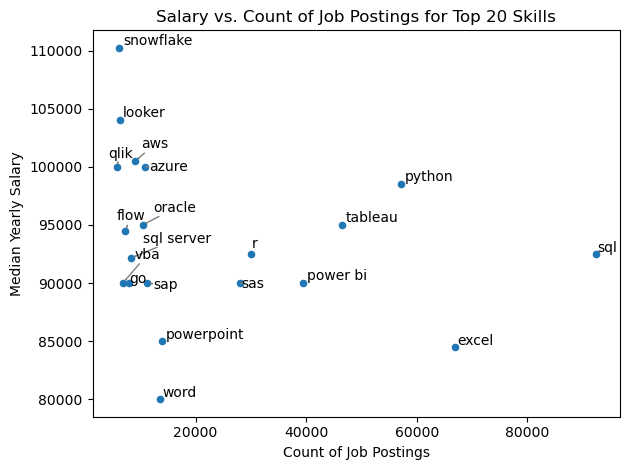

In [ ]:
# fig, ax = plt.subplots()

from adjustText import adjust_text

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary' )

texts = []
# lets make a empty list first
for i, txt in enumerate(skill_stats.index):
 texts.append(plt.text(skill_stats['skill_count']. iloc[i], skill_stats ['median_salary' ]. iloc[i], txt) )
#  these must go inside that list so did append 

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='grey', lw=1))

ax = plt.gca()

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt. title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')
plt.tight_layout()
plt.show()

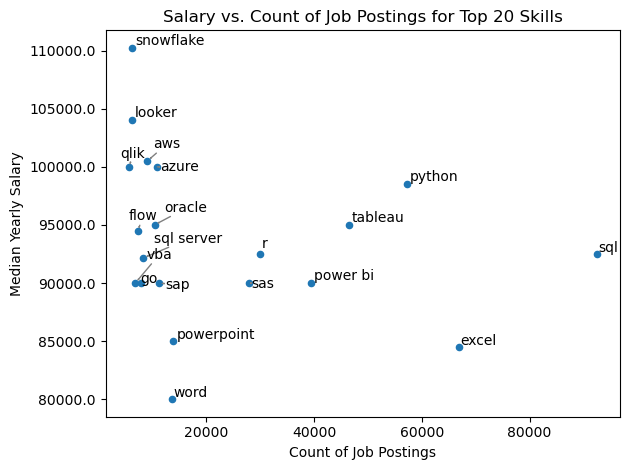

In [112]:
# fig, ax = plt.subplots()

from adjustText import adjust_text

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary' )

texts = []
# lets make a empty list first
for i, txt in enumerate(skill_stats.index):
 texts.append(plt.text(skill_stats['skill_count']. iloc[i], skill_stats ['median_salary' ]. iloc[i], txt) )
#  these must go inside that list so did append 

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='grey', lw=1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: y))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt. title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')
plt.tight_layout()
plt.show()

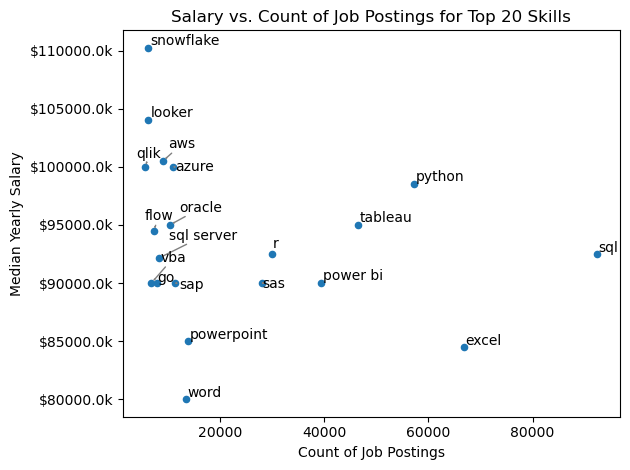

In [113]:
# fig, ax = plt.subplots()

from adjustText import adjust_text

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary' )

texts = []
# lets make a empty list first
for i, txt in enumerate(skill_stats.index):
 texts.append(plt.text(skill_stats['skill_count']. iloc[i], skill_stats ['median_salary' ]. iloc[i], txt) )
#  these must go inside that list so did append 

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='grey', lw=1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos:f'${y}k'))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt. title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')
plt.tight_layout()
plt.show()

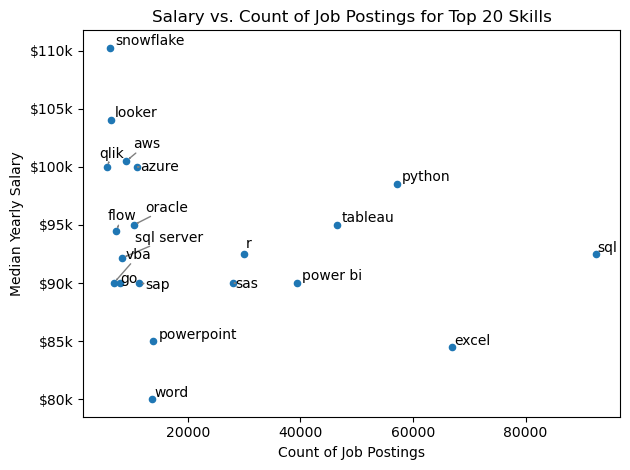

In [114]:
# fig, ax = plt.subplots()

from adjustText import adjust_text

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary' )

texts = []
# lets make a empty list first
for i, txt in enumerate(skill_stats.index):
 texts.append(plt.text(skill_stats['skill_count']. iloc[i], skill_stats ['median_salary' ]. iloc[i], txt) )
#  these must go inside that list so did append 

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='grey', lw=1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos:f'${int(y/1000)}k'))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt. title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')
plt.tight_layout()
plt.show()

this is difficult but no need to memorize just try to understand

---

# ***Matplotlib: Histograms***

In [115]:

# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train' ].to_pandas ()

# Data Cleanup
df ['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df ['job_skills' ] = df ['job_skills'].apply(lambda x: ast. literal_eval(x) if pd.notna(x) else x)

In [116]:
# Only get data analyst jobs in the US
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df ['job_country' ] == 'United States' ) ]. copy()

<Axes: ylabel='Frequency'>

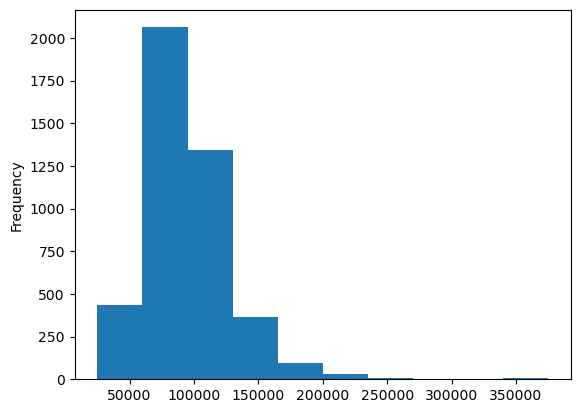

In [117]:
df_DA_US['salary_year_avg' ].plot(kind='hist')
                                

<Axes: ylabel='Frequency'>

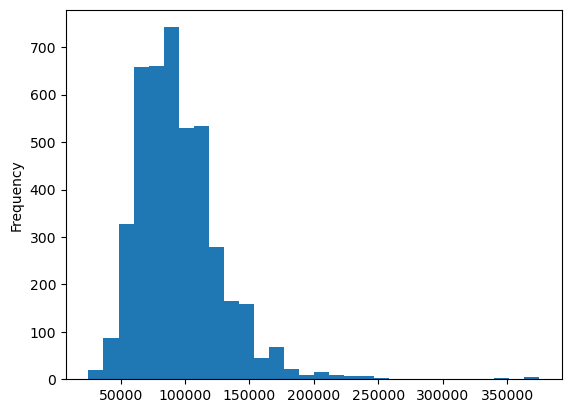

In [119]:
df_DA_US['salary_year_avg' ].plot(kind='hist', bins=30)


<Axes: ylabel='Frequency'>

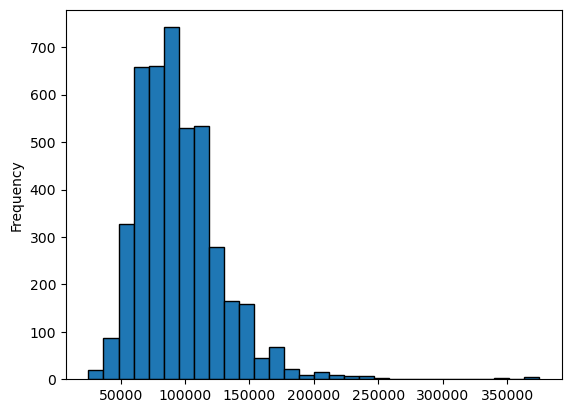

In [120]:
df_DA_US['salary_year_avg' ].plot(kind='hist', bins=30 , edgecolor= 'black')


but x values are too far

(0.0, 250000.0)

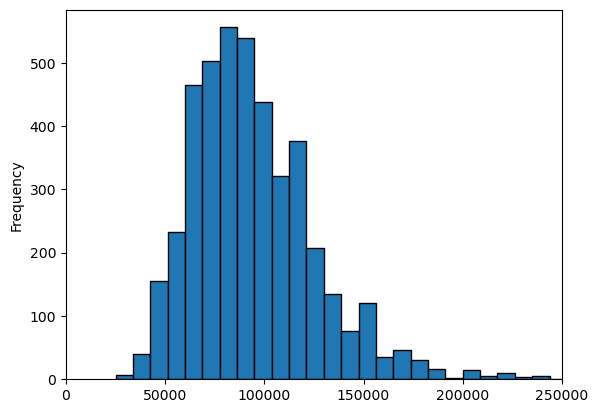

In [122]:
df_DA_US['salary_year_avg' ].plot(kind='hist', bins=40 , edgecolor= 'black')
plt.xlim(0,250000)

now lets format x axis

Text(0, 0.5, 'Number of Jobs')

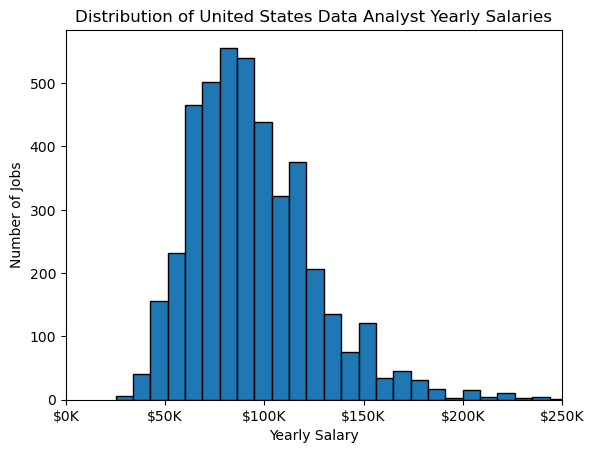

In [126]:
df_DA_US['salary_year_avg' ].plot(kind='hist', bins=40 , edgecolor= 'black')
plt.xlim(0,250000)
ax = plt.gca()
ax.xaxis. set_major_formatter(plt. FuncFormatter(lambda x, _: f'${int(x/1000)}K')) 
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')

---

# ***Matplotlib: Box Plots***

In [128]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset ['train' ]. to_pandas ()

# Data Cleanup
df ['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df ['job_skills'] = df ['job_skills'].apply(lambda x: ast. literal_eval(x) if pd. notna(x) else x) 

In [130]:
# Only get data analyst jobs
df_DA_US = df [(df ['job_title_short' ] == 'Data Analyst') & (df ['job_country' ]== 'United States') ]. copy()

# Drop NaN values from the column for plotting
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US['salary_year_avg']

109        89000.0
180        90250.0
410       133285.0
988        62623.0
1413       71300.0
            ...   
782637     70000.0
782798    111175.0
783588    125000.0
783866    115000.0
784882     87500.0
Name: salary_year_avg, Length: 4350, dtype: float64

<Axes: >

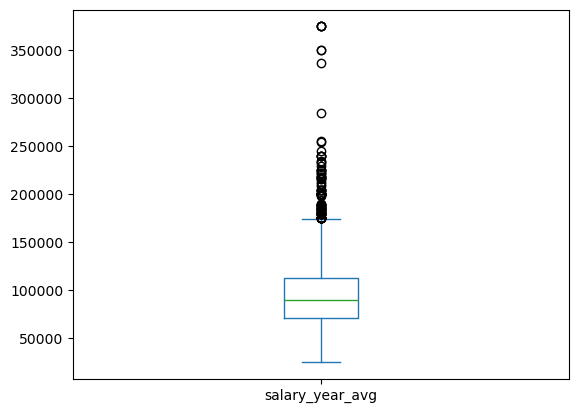

In [ ]:
df_DA_US['salary_year_avg'].plot(kind='box' )

for matplotlib :-

{'whiskers': [<matplotlib.lines.Line2D at 0x228d260cb50>,
 'caps': [<matplotlib.lines.Line2D at 0x228d260de10>,
 'boxes': [<matplotlib.lines.Line2D at 0x228d260c290>],
 'medians': [<matplotlib.lines.Line2D at 0x228d260ef50>],
 'fliers': [<matplotlib.lines.Line2D at 0x228d260f850>],
 'means': []}

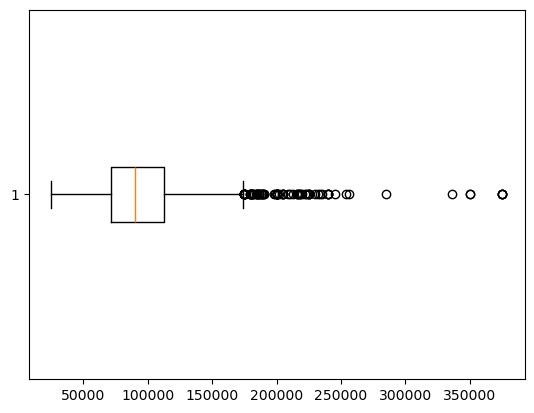

In [133]:
plt.boxplot(df_DA_US['salary_year_avg'], vert= False)

we generally have :- 

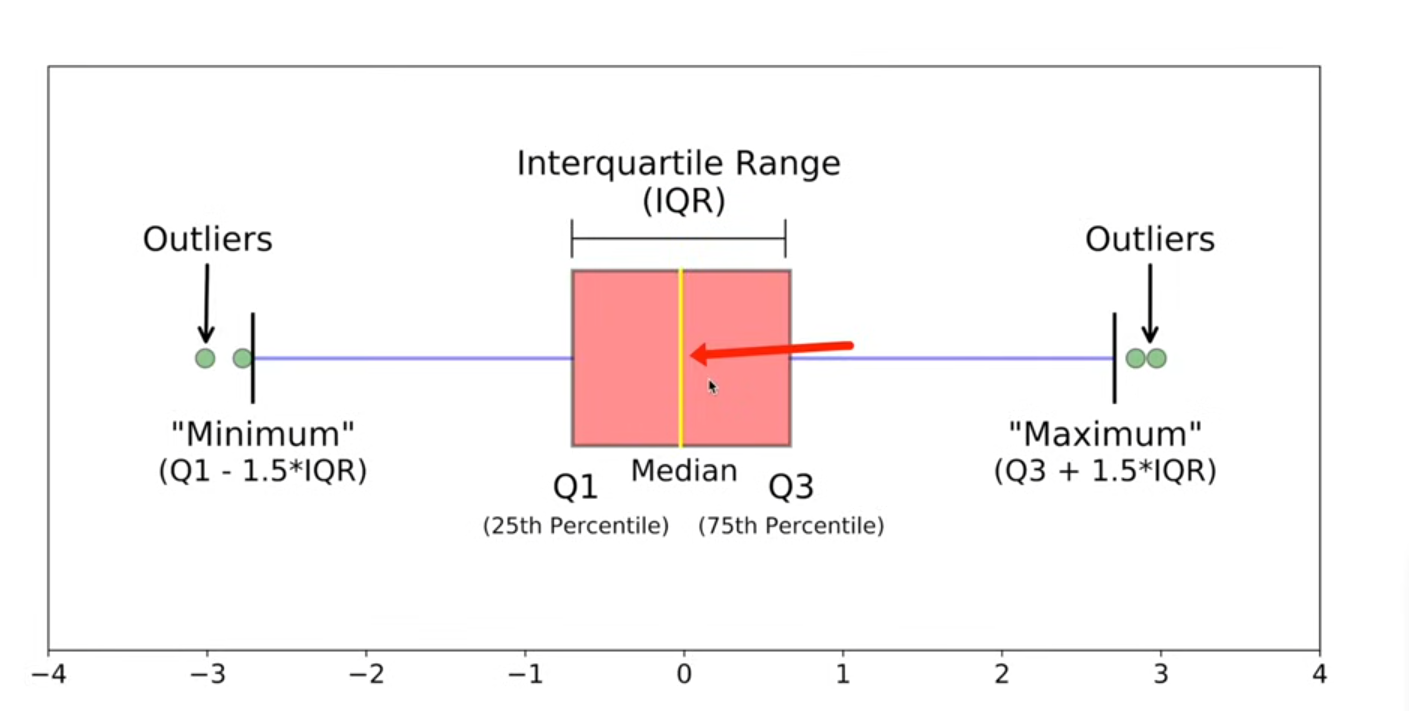

box and whiskers chart

### Box Plot and Interquartile Range (IQR) Explanation

This diagram explains how a **box plot** represents the distribution of data and how **outliers are detected using the Interquartile Range (IQR)**.

A box plot summarizes data using five main statistics: **Minimum, Q1, Median, Q3, and Maximum**.

**Q1 (First Quartile – 25th percentile)**  
This is the value below which **25% of the data lies**.

**Median (50th percentile)**  
The middle value of the dataset where **50% of the values are below it and 50% are above it**.  
In the diagram, it is shown as the **yellow line inside the box**.

**Q3 (Third Quartile – 75th percentile)**  
This is the value below which **75% of the data lies**.

The **box** in the box plot represents the **Interquartile Range (IQR)**:
IQR = Q3 − Q1


The IQR contains the **middle 50% of the data**, which is why it is a good measure of the spread of the central data.

The **whiskers** extend from the box to the minimum and maximum values that are still considered normal (non-outliers).

The boundaries for detecting outliers are calculated as:
Lower Bound = Q1 − 1.5 × IQR
Upper Bound = Q3 + 1.5 × IQR


Any values **smaller than Q1 − 1.5 × IQR** or **greater than Q3 + 1.5 × IQR** are considered **outliers**.

In the diagram:
- The **green dots** represent outliers.
- The **black vertical lines** show the limits of normal data (the whisker ends).
- The **red box** represents the middle 50% of the data (IQR).
- The **yellow line inside the box** is the median.

Box plots are commonly used in **data analysis to quickly understand the spread, central tendency, and presence of outliers in a dataset**.

now  we want for the data jobs ie  plt.boxplot(job_list,labels=job_titles, vert=False)

In [137]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_US = df[(df['job_title_short'].isin(job_titles) ) & (df ['job_country'] == 'United States' ) ]. copy()
df_US = df_US.dropna(subset= ['salary_year_avg'])

In [138]:
df_US['job_title_short'].value_counts()

job_title_short
Data Scientist    4553
Data Analyst      4350
Data Engineer     2915
Name: count, dtype: int64

In [139]:
df_US['salary_year_avg']

92        120000.0
100       228222.0
109        89000.0
116       114000.0
146       129500.0
            ...   
785563    136400.0
785624    139216.0
785641    150000.0
785648    221875.0
785692    157500.0
Name: salary_year_avg, Length: 11818, dtype: float64

since we have to do this plt.boxplot(job_list,labels=job_titles, vert=False) there for job list we need to do list comprehension

C:\Users\acer\AppData\Local\Temp\ipykernel_7612\664186754.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


{'whiskers': [<matplotlib.lines.Line2D at 0x228d26c4f50>,
 'caps': [<matplotlib.lines.Line2D at 0x228d26c6dd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x228d26c4890>,
 'medians': [<matplotlib.lines.Line2D at 0x228d26c8bd0>,
 'fliers': [<matplotlib.lines.Line2D at 0x228d26c9510>,
 'means': []}

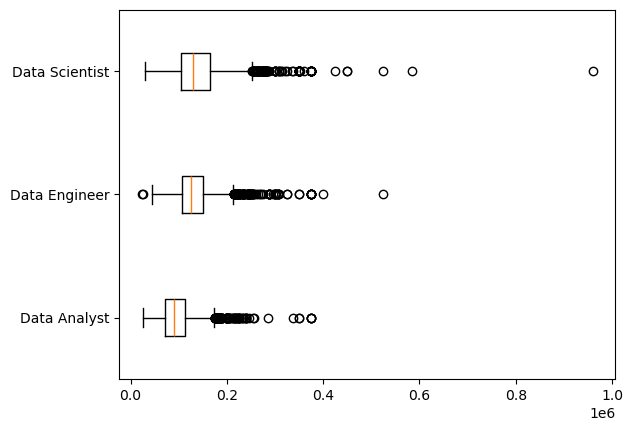

In [145]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

# filter the data to appropriate job _titles
df_US = df[(df['job_title_short']. isin(job_titles) ) & (df ['job_country' ] == 'United States' ) ].copy()
df_US = df_US.dropna(subset=['salary_year_avg'])

job_list = [df_US[df_US['job_title_short' ] == job_title] ['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)



C:\Users\acer\AppData\Local\Temp\ipykernel_7612\2646203373.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


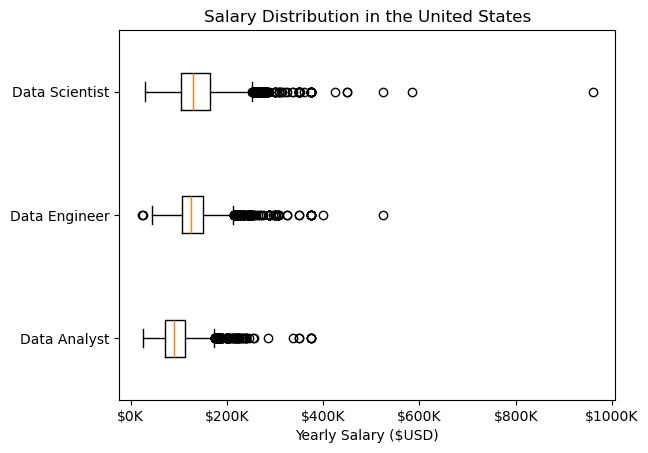

In [ ]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

# filter the data to appropriate job _titles
df_US = df[(df['job_title_short']. isin(job_titles) ) & (df ['job_country' ] == 'United States' ) ].copy()
df_US = df_US.dropna(subset=['salary_year_avg'])

job_list = [df_US[df_US['job_title_short' ] == job_title] ['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
ax = plt.gca()
ax.xaxis. set_major_formatter(plt. FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt. show()

C:\Users\acer\AppData\Local\Temp\ipykernel_7612\2239450209.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


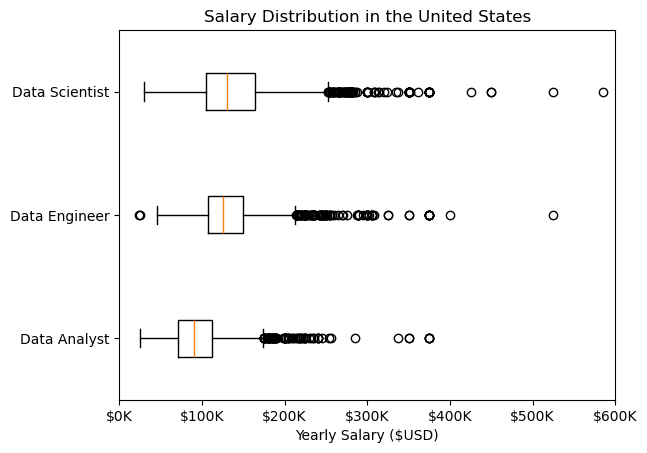

In [148]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

# filter the data to appropriate job _titles
df_US = df[(df['job_title_short']. isin(job_titles) ) & (df ['job_country' ] == 'United States' ) ].copy()
df_US = df_US.dropna(subset=['salary_year_avg'])

job_list = [df_US[df_US['job_title_short' ] == job_title] ['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
ax = plt.gca()
ax.xaxis. set_major_formatter(plt. FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt. show()

---

# ***Exercise: Skill Pay Analysis***

In [149]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset ['train' ]. to_pandas ()

# Data Cleanup
df ['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df ['job_skills'] = df ['job_skills'].apply(lambda x: ast. literal_eval(x) if pd.notna(x) else x)

In [150]:
# Only get data analyst jobs in the US
df_DA_US = df [(df ['job_title_short' ] == 'Data Analyst') & (df ['job_country' ] == 'United States' ) ]. copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

In [153]:
df_DA_US = df_DA_US.explode('job_skills')

df_DA_US[ ['salary_year_avg', 'job_skills']]

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel
...,...,...
784882,87500.0,sql
784882,87500.0,vba
784882,87500.0,tableau
784882,87500.0,excel


we need to create 2 new df based on salary and skill and groupby

In [154]:
df_DA_US.groupby('job_skills') ['salary_year_avg'].agg(['count', 'median'])


,count,median
job_skills,,
airflow,44,116250.00
airtable,5,90000.00
alteryx,106,106281.25
angular,8,107500.00
ansible,1,159640.00
...,...,...
wire,4,74250.00
word,461,81194.75
workfront,3,75000.00


In [155]:
df_DA_US_group= df_DA_US.groupby('job_skills') ['salary_year_avg'].agg(['count', 'median'])


now we need top 10 in salary and count

In [156]:
df_DA_US_group = df_DA_US.groupby('job_skills') ['salary_year_avg'].agg(['count', 'median'])

df_DA_top_pay = df_DA_US_group.sort_values(by='median', ascending=False).head(10)

df_DA_skills = df_DA_US_group.sort_values(by='count', ascending=False).head(10)

since we are suing two plots here so we need to use subplot

<Axes: ylabel='job_skills'>

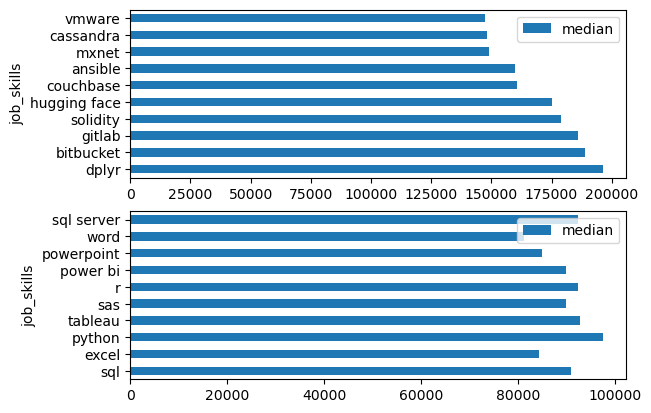

In [157]:
fig, ax = plt.subplots(2, 1)

df_DA_top_pay.plot(kind='barh', y='median', ax=ax[0])

df_DA_skills.plot(kind='barh', y='median', ax=ax[1])

In [ ]:
df_DA_skills = df_DA_US_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)
# sorting two times

# or we can use df_DA_top_pay[ ::- 1]

<Axes: ylabel='job_skills'>

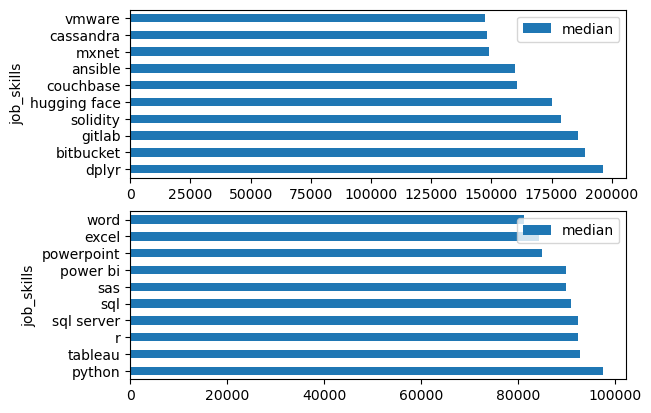

In [159]:
fig, ax = plt.subplots(2, 1)

df_DA_top_pay.plot(kind='barh', y='median', ax=ax[0])

df_DA_skills.plot(kind='barh', y='median', ax=ax[1])

(0.0, 206062.5)

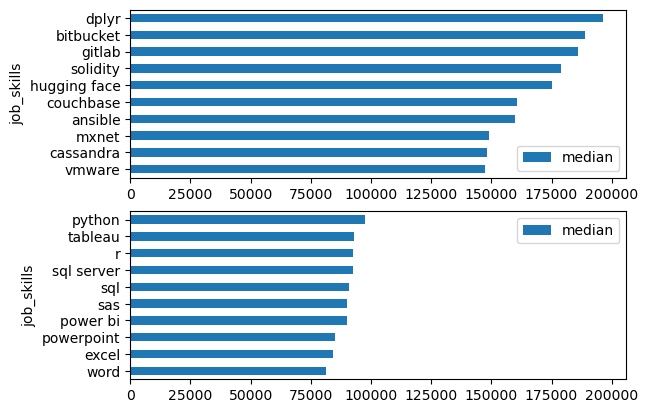

In [161]:
fig, ax = plt.subplots(2, 1)

df_DA_top_pay[ ::- 1].plot(kind='barh', y='median', ax=ax[0])
# this means calling data frame in reverse order so our graph will reverse.. there are many more methods which we can use

df_DA_skills[ ::- 1].plot(kind='barh', y='median', ax=ax[1])
ax[1].set_xlim(ax[0].get_xlim())
# this will get us x limit same like top graph

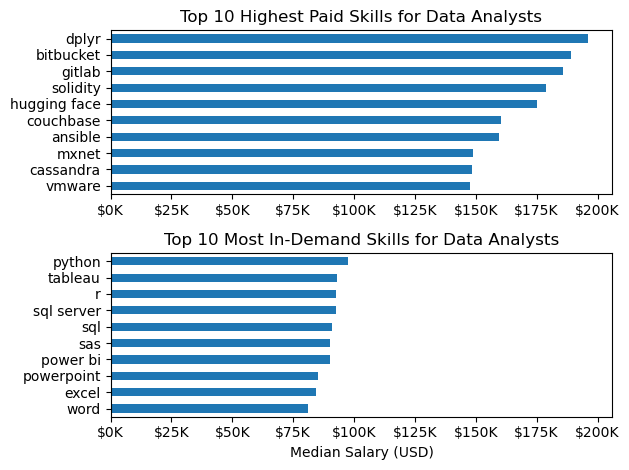

In [165]:
fig, ax = plt.subplots(2, 1)

df_DA_top_pay[ ::- 1].plot(kind='barh', y='median', ax=ax[0], legend= False)
ax [0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax [0].set_ylabel('')
ax [0].set_xlabel('')
ax [0].xaxis. set_major_formatter(plt. FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

df_DA_skills[ ::- 1].plot(kind='barh', y='median', ax=ax[1], legend= False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax [1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
fig.tight_layout()

---


# ***Seaborn: Intro***

extension of matplotlib that gives us more visually appealing figures with less code

[seaborn](https://seaborn.pydata.org)

In [166]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas ()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df ['job_skills'] = df ['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

now install and import seaborn

In [168]:
import seaborn as sns

In [169]:
# Only get data analyst jobs in the US
df_DA_US = df [(df['job_title_short'] == 'Data Analyst') & (df['job_country' ] == 'United States' ) ]. copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_DA_US = df_DA_US. dropna(subset=['salary_year_avg'])

now the bar charts we created in the last exesice

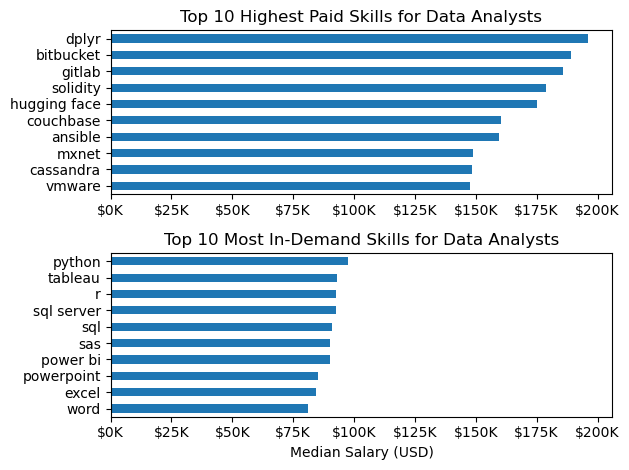

In [171]:
df_DA_US = df_DA_US.explode('job_skills')

df_DA_top_pay = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='median', ascending=False)
df_DA_top_pay =df_DA_top_pay.head(10)

df_DA_skills = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)
df_DA_skills = df_DA_skills.head(10).sort_values(by='median', ascending=False)

fig, ax = plt.subplots(2, 1)

# Top 10 Highest Paid Skills for Data Analysts
df_DA_top_pay[ ::- 1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax [0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# Top 10 Most In-Demand Skills for Data Analysts
df_DA_skills[ ::- 1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim()) # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt. show()



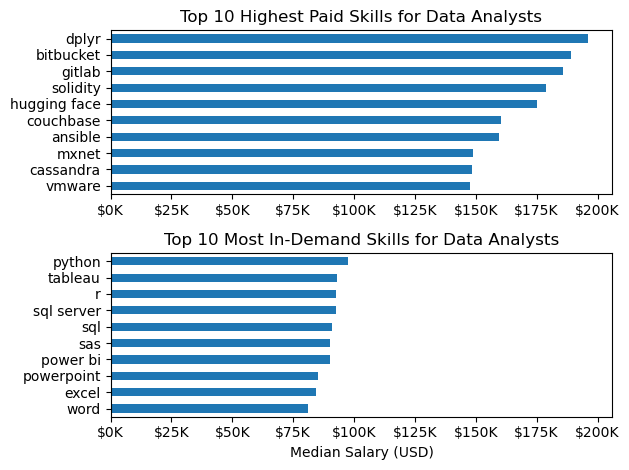

In [173]:
fig, ax = plt.subplots(2, 1)
df_DA_top_pay[ ::- 1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax [0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# Top 10 Most In-Demand Skills for Data Analysts
df_DA_skills[ ::- 1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim()) # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt. show()

### `seaborn.barplot()`: Visualize Aggregated Data with Error Bars

`seaborn.barplot()` is a powerful function for showing the central tendency (like the mean or median) of a numerical variable for different categories. It represents this estimate with a bar and often includes error bars to indicate the uncertainty around that estimate.

**Simple Terms:** It's great for comparing quantities across different groups. Think of it as a way to say "On average, how much of X do we have in category A versus category B?" and also show how consistent those averages are.

**Key Use Cases:**
*   Comparing average sales per region.
*   Showing the mean score for different test groups.
*   Visualizing the frequency or count of categorical data (if aggregated first).

**Syntax (Common Usage):**

```python
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df, x='category_column', y='numeric_column', hue='another_category', estimator='mean', errorbar=('ci', 95), palette='viridis')
plt.show()
```

**Key Parameters Explained:**

*   `data`: The DataFrame containing your data. This is where `x`, `y`, and `hue` will look for columns.
*   `x`: The name of the column to plot on the horizontal axis (usually your categorical variable).
*   `y`: The name of the column to plot on the vertical axis (usually your numerical variable for aggregation).
*   `hue`: (Optional) The name of a column to create separate bars for different sub-categories within each `x` category (e.g., comparing 'sales' by 'region' and then further by 'product type').
*   `estimator`: The statistical function to estimate within each category. Common choices are `'mean'` (default), `'median'`, `sum`, `len` (for counts), `min`, `max`.
*   `errorbar`: Controls how error bars are displayed. By default, `('ci', 95)` shows a 95% confidence interval. Other options include `('sd')` for standard deviation or `None` to hide error bars.
*   `palette`: (Optional) A set of colors to use for the different bars, especially useful with `hue`. You can provide:
    *   The name of a Seaborn palette (e.g., `'viridis'`, `'pastel'`, `'deep'`).
    *   The name of a Matplotlib colormap (e.g., `'Reds'`, `'Blues'`).
    *   A list of custom colors (e.g., `['red', 'blue', 'green']`).
    *   A dictionary mapping `hue` levels to specific colors for fine-grained control.
*   `ax`: (Optional) The Matplotlib Axes object to draw the plot on. Useful when creating multiple subplots.


[color pallets link](https://seaborn.pydata.org/tutorial/color_palettes.html)

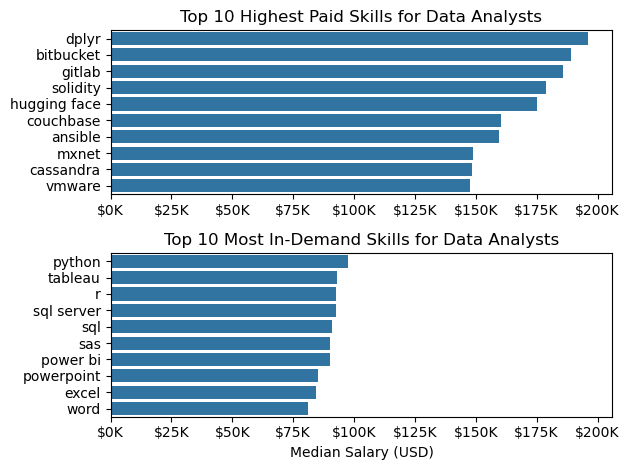

In [174]:
fig, ax = plt.subplots(2, 1)

# Top 10 Highest Paid Skills for Data Analysts
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay. index, ax=ax[0])

# df_DA_top_pay[ ::- 1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax [0].set_ylabel('')
ax [0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# Top 10 Most In-Demand Skills for Data Analysts
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, ax=ax[1])

# df_DA_skills[ ::- 1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim()) # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt. show()

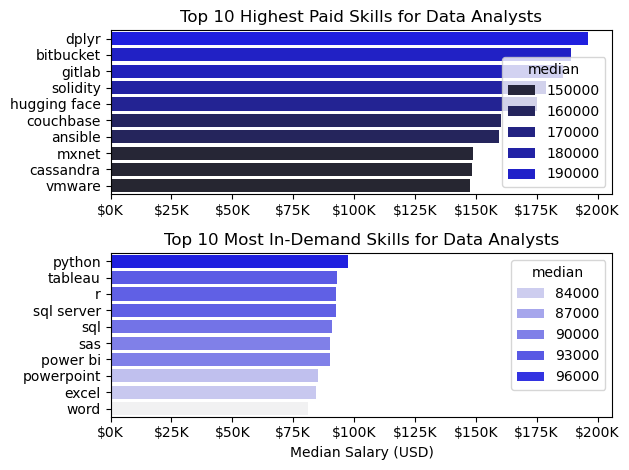

In [175]:
fig, ax = plt.subplots(2, 1)

# Top 10 Highest Paid Skills for Data Analysts
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='dark:b' )

# df_DA_top_pay[ ::- 1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax [0].set_ylabel('')
ax [0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# Top 10 Most In-Demand Skills for Data Analysts
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills. index, ax=ax[1], hue='median', palette='light:b' )

# df_DA_skills[ ::- 1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim()) # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout ()
plt. show()

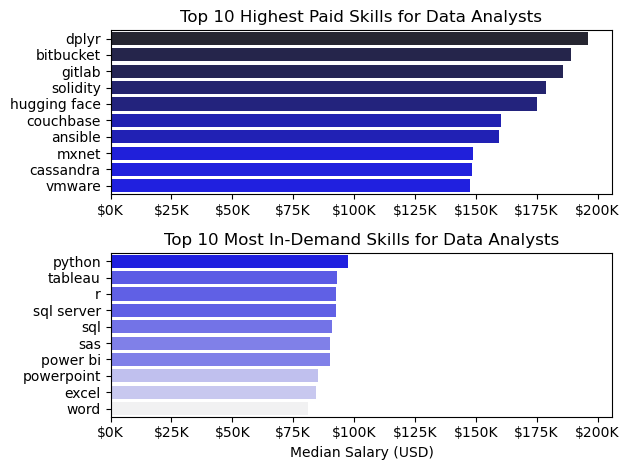

In [177]:
fig, ax = plt.subplots(2, 1)

# Top 10 Highest Paid Skills for Data Analysts
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r' )
ax[0]. legend () . remove()

# df_DA_top_pay[ ::- 1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax [0].set_ylabel('')
ax [0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# Top 10 Most In-Demand Skills for Data Analysts
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills. index, ax=ax[1], hue='median', palette='light:b' )
ax[1]. legend () . remove()

# df_DA_skills[ ::- 1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim()) # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout ()
plt. show()

we can also change the theme of bars see the webiste

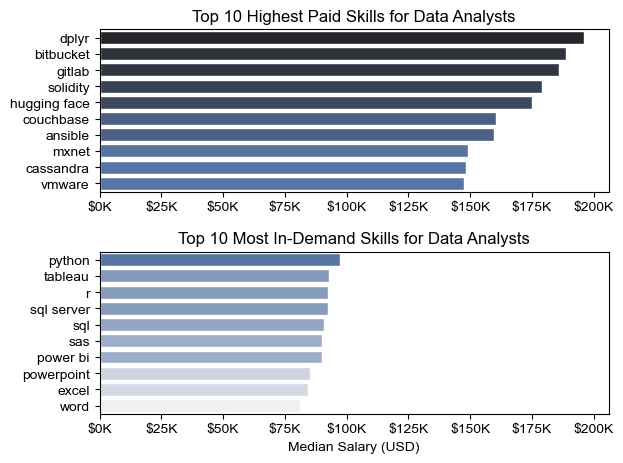

In [ ]:
fig, ax = plt.subplots(2, 1)
sns.set_theme(style="ticks", )
# Top 10 Highest Paid Skills for Data Analysts
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r' )
# b means blue
ax[0]. legend () . remove()

# df_DA_top_pay[ ::- 1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax [0].set_ylabel('')
ax [0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# Top 10 Most In-Demand Skills for Data Analysts
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills. index, ax=ax[1], hue='median', palette='light:b' )
ax[1]. legend () . remove()

# df_DA_skills[ ::- 1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim()) # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout ()
plt. show()

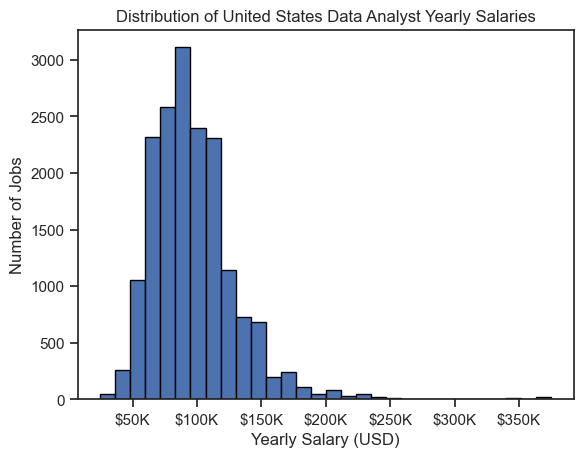

In [181]:
df_DA_US['salary_year_avg'].plot(kind='hist', bins=30, edgecolor='black')

plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Jobs')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt. FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()

### `seaborn.histplot()`: Plot Data Distributions

`seaborn.histplot()` is a versatile function used to visualize the distribution of one or two variables using histograms. It counts observations within discrete bins and can optionally display a smoothed curve (KDE).

**Simple Terms:** It helps you understand how often different values appear in your data. For example, if you have a list of student scores, a histplot can show you how many students scored between 0-10, 10-20, etc.

**Key Use Cases:**
*   Showing the distribution of a single numerical variable (univariate).
*   Showing the joint distribution of two numerical variables (bivariate).
*   Comparing distributions across different categories within a dataset.

**Syntax (Common Usage):**

```python
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x='numeric_column', hue='category_column', kde=True, bins=20, palette='viridis')
plt.show()
```

but for smooth curves

### `seaborn.displot()`: Figure-Level Distribution Plotting

`seaborn.displot()` is a high-level (figure-level) function in Seaborn that provides a unified way to visualize the distribution of one or two variables. It's especially powerful because it can easily create multiple plots (facets) based on different categories in your data.

**Simple Terms:** Think of `displot()` as a smart wrapper that can draw histograms (`histplot`), kernel density estimates (`kdeplot`), or empirical cumulative distribution functions (`ecdfplot`) for you. Its main advantage is simplifying the creation of grids of plots to compare distributions across different subgroups.

**Key Use Cases:**
*   Quickly visualizing distributions using different plot types (hist, kde, ecdf).
*   Comparing distributions across different categories by automatically creating subplots (facets).
*   Exploring both univariate (single variable) and bivariate (two variables) distributions.

**Syntax (Common Usage):**

```python
import seaborn as sns
import matplotlib.pyplot as plt

sns.displot(data=df, x='numeric_column', hue='category_for_color', col='category_for_subplots', kind='hist', kde=True, height=4, aspect=1.2, palette='viridis')
plt.show()
```

**Key Parameters Explained:**

*   `data`: The DataFrame containing your data.
*   `x`, `y`: The column(s) for which you want to plot the distribution. `x` for univariate, `x` and `y` for bivariate.
*   `hue`: (Optional) A categorical column whose unique values will determine different colors within the plot, allowing you to compare distributions.
*   `row`, `col`: (Optional) Categorical columns to create rows or columns of subplots (facets). Each unique value in these columns will get its own subplot.
*   `kind`: Specifies the type of plot to draw: `'hist'` (histogram, default), `'kde'` (kernel density estimate), or `'ecdf'` (empirical cumulative distribution function).
*   `kde`: If `kind='hist'` (or not specified) and `kde=True`, a Kernel Density Estimate line will be drawn on top of the histogram.
*   `palette`: (Optional) A set of colors to use for different `hue` categories. Similar to `barplot()`.
*   `height`: Height of each facet (in inches).
*   `aspect`: Aspect ratio of each facet, so `width = height * aspect`.
*   `**kwargs`: Additional keyword arguments are passed directly to the underlying plotting function (e.g., `histplot`, `kdeplot`). So, parameters like `bins`, `binwidth`, `stat`, `multiple` (for histograms) or `fill` (for KDEs) would be passed here.

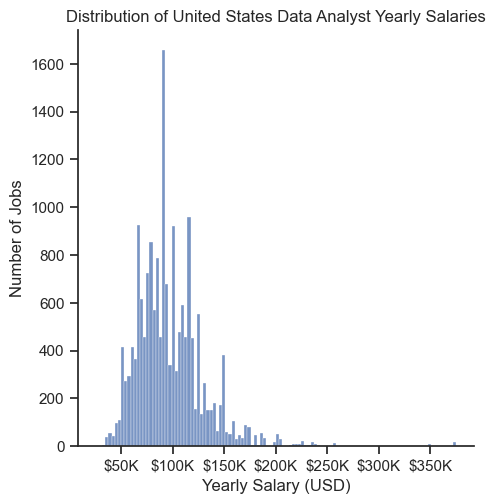

In [182]:
sns.displot(df_DA_US['salary_year_avg'])
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Jobs')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt. FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()

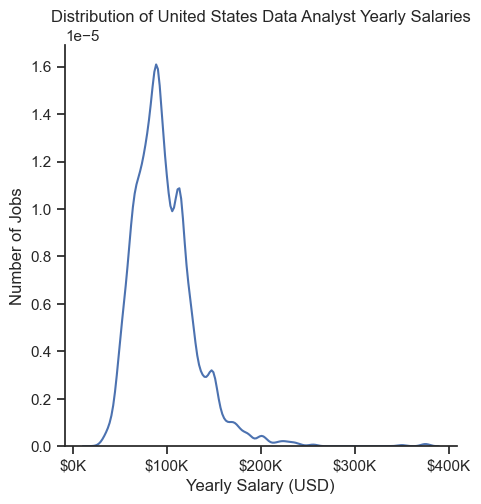

In [183]:
sns.displot(df_DA_US['salary_year_avg'],kind='kde')
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Jobs')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt. FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()

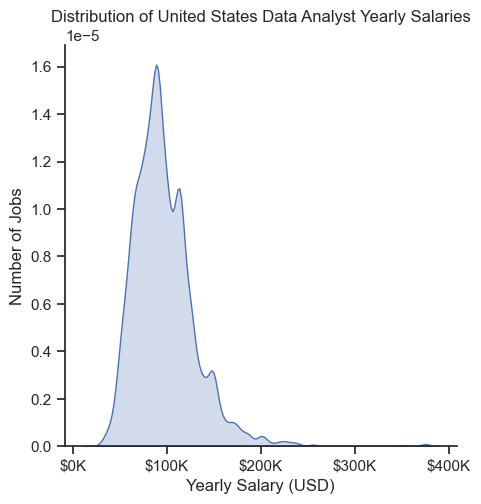

In [185]:
sns.set_theme(style="ticks")
sns.displot(df_DA_US['salary_year_avg'],kind='kde', fill=True)
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('Number of Jobs')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt. FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.show()

### `seaborn.boxplot()`: Draw a Box Plot

`seaborn.boxplot()` is used to visualize the distribution of quantitative data, especially for comparing distributions across different categories. It shows the median, quartiles, and potential outliers of a dataset.

**Simple Terms:** A box plot gives you a quick visual summary of the data spread. The 'box' shows the middle 50% of your data, the line inside is the median, and the 'whiskers' extend to cover most of the remaining data, with individual points showing 'outliers'. It's excellent for seeing how different groups compare in terms of their central tendency and spread.

**Key Use Cases:**
*   Comparing the salary distributions across different job titles.
*   Showing the range of test scores for various student groups.
*   Identifying outliers in a dataset.

**Syntax (Common Usage):**

```python
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x='category_column', y='numeric_column', hue='another_category', palette='viridis')
plt.show()
```

**Key Parameters Explained:**

*   `data`: The DataFrame containing your data.
*   `x`, `y`: The column(s) for which you want to plot the distribution. One is typically categorical (for groups) and the other is numerical (for distribution).
*   `hue`: (Optional) A categorical column whose unique values will determine different colors within the plot, allowing for additional grouping.
*   `orient`: Orientation of the plot (`'v'` for vertical boxes, `'h'` for horizontal boxes). Often inferred from `x` and `y`.
*   `palette`: (Optional) A set of colors to use for different `hue` categories or overall plot elements.
*   `whis`: Determines the extent of the whiskers. Default is 1.5, meaning whiskers extend to 1.5 * IQR (Interquartile Range) from the box.
*   `linewidth`: Thickness of the box and whisker lines.
*   `fliersize`: Size of the markers for outlier points.
*   `ax`: (Optional) The Matplotlib Axes object to draw the plot on. Useful when creating multiple subplots.

C:\Users\acer\AppData\Local\Temp\ipykernel_7612\1528002989.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


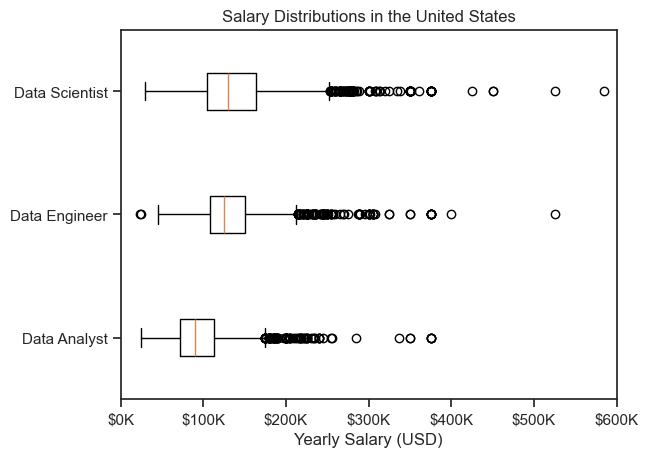

In [187]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

# filter for the job titles and country
df_US = df[(df['job_title_short'].isin(job_titles) ) & (df['job_country'] == 'United States' ) ].dropna(subset=['salary_year_avg'])

# list of salaries for each job title
job_list = [df_US[df_US['job_title_short'] == job_title] ['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary Distributions in the United States')
plt.xlabel('Yearly Salary (USD)')
plt.xlim(0, 600000)
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt. show( )

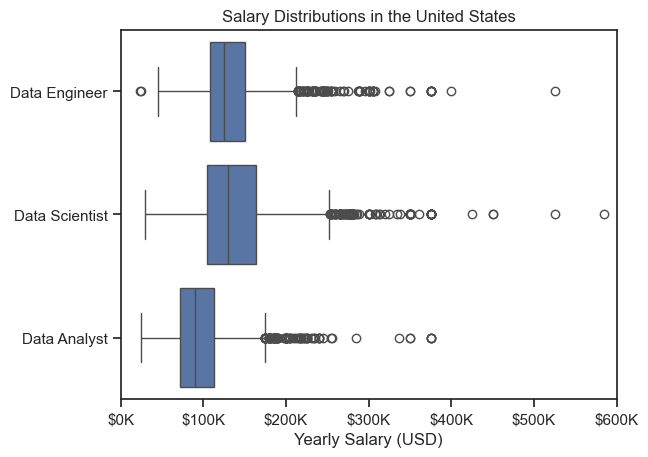

In [192]:
sns.boxplot(data=df_US, x='salary_year_avg', y='job_title_short')

plt.title('Salary Distributions in the United States')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000)
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt. show( )

---